In [1]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

#### Question 1 - Extracting Tesla Stock Data Using yfinance - 2 Points

In [2]:
tesla_ticker = yf.Ticker('TSLA')

In [3]:
tesla_data = tesla_ticker.history(period='max')
tesla_data.reset_index(inplace=True)

In [18]:
#tesla_data.info()
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


#### Question 2 - Extracting Tesla Revenue Data Using Webscraping - 1 Points

In [12]:
from io import StringIO

url_tesla = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url_tesla).text

all_tables = pd.read_html(StringIO(html_data))

tesla_revenue = all_tables.pop(1)

tesla_revenue.columns = ["Date", "Revenue"]

tesla_revenue["Revenue"] = tesla_revenue['Revenue'].astype(str).str.replace(r'[\$,]', '', regex=True)

tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

tesla_revenue.tail()

,Date,Revenue
49,2010-06-30,28
50,2010-03-31,21
51,2009-12-31,nan
52,2009-09-30,46
53,2009-06-30,27


#### Question 3 - Extracting GameStop Stock Data Using yfinance

In [13]:
gme_ticker = yf.Ticker("GME")

gme_data = gme_ticker.history(period="max")

gme_data.reset_index(inplace=True)

gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


#### Question 4 - Extracting GameStop Revenue Data Using Webscraping

In [14]:
url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_gme = requests.get(url_gme).text

all_gme_tables = pd.read_html(StringIO(html_data_gme))

gme_revenue = all_gme_tables.pop(1)

gme_revenue.columns = ["Date", "Revenue"]

gme_revenue["Revenue"] = gme_revenue['Revenue'].astype(str).str.replace(r'[\$,]', '', regex=True)

gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


In [15]:
def make_graph(stock_data, revenue_data, stock):
    """
    Creates a dual-axis visual dashboard showing historical share price and revenue.
    """
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                        subplot_titles=("Historical Share Price", "Historical Revenue"), 
                        vertical_spacing=0.3)
    
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']
    
    # Share Price
    fig.add_trace(go.Scatter(x=pd.to_datetime(stock_data_specific.Date), 
                             y=stock_data_specific.Close.astype("float"), 
                             name="Share Price"), row=1, col=1)
    
    # Revenue
    fig.add_trace(go.Scatter(x=pd.to_datetime(revenue_data_specific.Date), 
                             y=revenue_data_specific.Revenue.astype("float"), 
                             name="Revenue"), row=2, col=1)
    
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)
    
    fig.update_layout(showlegend=False, height=900, title=stock, xaxis_rangeslider_visible=True)
    fig.show()

#### Question 5 - Tesla Stock and Revenue Dashboard

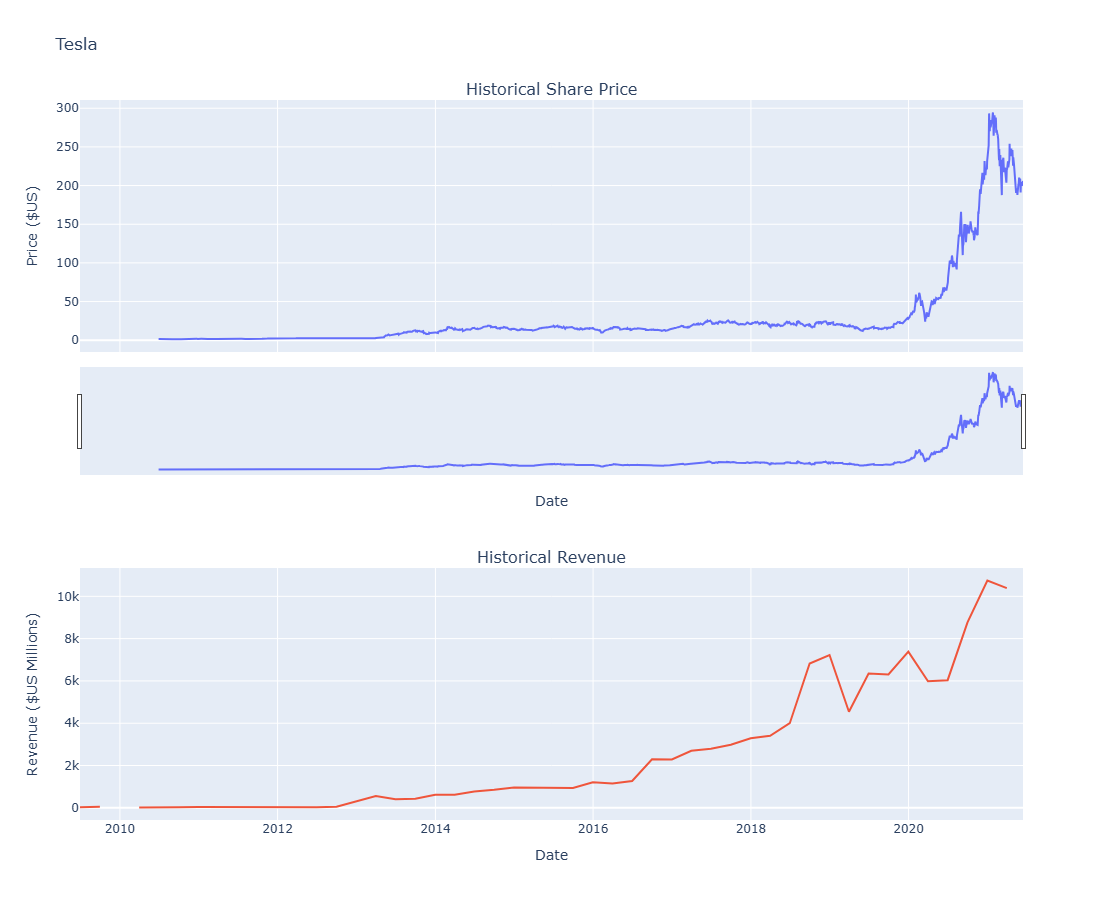

In [16]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

#### Question 6 - GameStop Stock and Revenue Dashboard

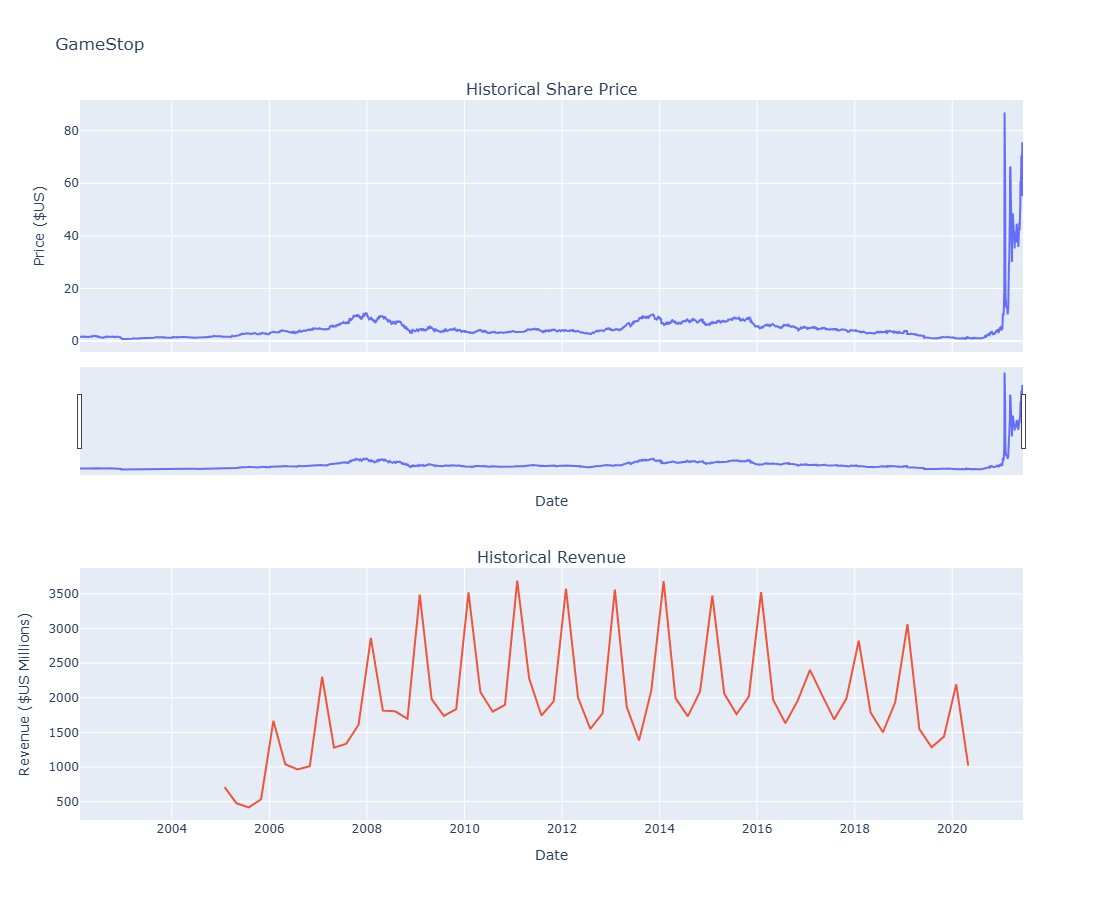

In [17]:
make_graph(gme_data, gme_revenue, 'GameStop')

#### Question 7 - Sharing your Assignment Notebook

###### going to share the file in submission tab